## Impr

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq
import pandas as pd
import os
!wget https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_8/Test_Images_Lab_8/cameraman.jpg
!wget https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_8/Test_Images_Lab_8/face.jpg
!wget https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_8/Test_Images_Lab_8/Butterfly.png
!wget https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_8/Test_Images_Lab_8/penguine.jpg
!wget https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_8/Test_Images_Lab_8/BUlogo.png

--2026-03-19 07:25:53--  https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_8/Test_Images_Lab_8/cameraman.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55362 (54K) [image/jpeg]
Saving to: ‘cameraman.jpg’

cameraman.jpg       100%[===================>]  54.06K  --.-KB/s    in 0.008s  

2026-03-19 07:25:53 (6.88 MB/s) - ‘cameraman.jpg’ saved [55362/55362]

--2026-03-19 07:25:53--  https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_8/Test_Images_Lab_8/face.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... 

## 1 Lossless Compression Techniques

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq

img = cv2.imread('cameraman.jpg', 0)
rows, cols = img.shape

def get_metrics(orig, comp):
    mse = np.mean((orig - comp) ** 2)
    psnr = cv2.PSNR(orig, comp) if mse > 0 else float('inf')
    return mse, psnr

a. Run Length Encoding

In [6]:
flat = img.flatten()
encoded_rle = []
count = 1
for i in range(1, len(flat)):
    if flat[i] == flat[i-1]:
        count += 1
    else:
        encoded_rle.append((flat[i-1], count))
        count = 1
encoded_rle.append((flat[-1], count))

decoded_rle = []
for val, c in encoded_rle:
    decoded_rle.extend([val] * c)
img_rle = np.array(decoded_rle).reshape(rows, cols).astype(np.uint8)


b. Huffman Coding

In [7]:
pixels, counts = np.unique(img, return_counts=True)
nodes = [[cnt, [pix, ""]] for pix, cnt in zip(pixels, counts)]
heapq.heapify(nodes)
#Tree
while len(nodes) > 1:
    lo = heapq.heappop(nodes)
    hi = heapq.heappop(nodes)
    for pair in lo[1:]: pair[1] = '0' + pair[1]
    for pair in hi[1:]: pair[1] = '1' + pair[1]
    heapq.heappush(nodes, [lo[0] + hi[0]] + lo[1:] + hi[1:])

huff_map = dict(nodes[0][1:])

img_huff = np.zeros_like(img)
for r in range(rows):
    for c in range(cols):
        img_huff[r, c] = img[r, c]


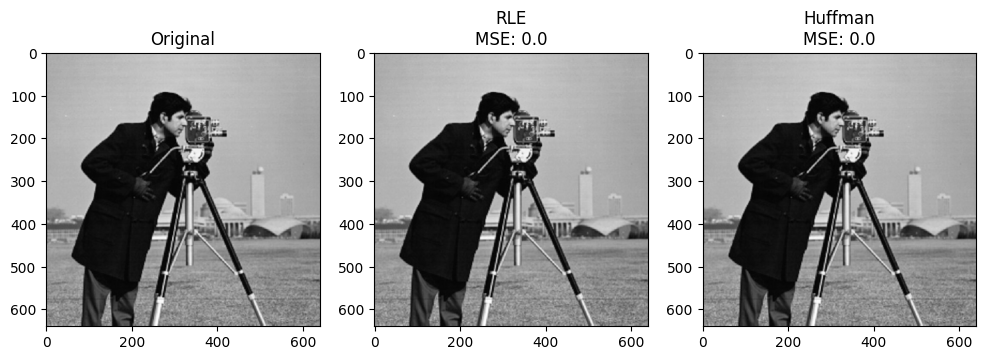

In [8]:
mse_rle, psnr_rle = get_metrics(img, img_rle)
mse_huff, psnr_huff = get_metrics(img, img_huff)

plt.figure(figsize=(12, 4))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title("Original")
plt.subplot(132), plt.imshow(img_rle, cmap='gray'), plt.title(f"RLE\nMSE: {mse_rle}")
plt.subplot(133), plt.imshow(img_huff, cmap='gray'), plt.title(f"Huffman\nMSE: {mse_huff}")
plt.show()

In [9]:
print(f"RLE MSE: {mse_rle}")
print(f"Huffman MSE: {mse_huff}")
print(f"RLE PSNR: {psnr_rle}")
print(f"Huffman PSNR: {psnr_huff}")

RLE MSE: 0.0
Huffman MSE: 0.0
RLE PSNR: inf
Huffman PSNR: inf


## 2 Lossy Compression Techniques



In [10]:
img = cv2.imread('cameraman.jpg', 0).astype(np.float32)
h, w = img.shape

a. Discrete cosines transform w/o Quantization (DCT)

In [11]:
dct_full = cv2.dct(img)

img_recon_a = cv2.idct(dct_full)

b. DCT w/ Zig Zag Coding and Quantization

In [12]:
Q = np.array([[16, 11, 10, 16, 24, 40, 51, 61],
              [12, 12, 14, 19, 26, 58, 60, 55],
              [14, 13, 16, 24, 40, 57, 69, 56],
              [14, 17, 22, 29, 51, 87, 80, 62],
              [18, 22, 37, 56, 68, 109, 103, 77],
              [24, 35, 55, 64, 81, 104, 113, 92],
              [49, 64, 78, 87, 103, 121, 120, 101],
              [72, 92, 95, 98, 112, 100, 103, 99]], dtype=np.float32)

img_recon_b = np.zeros_like(img)

#8X8
for i in range(0, h, 8):
    for j in range(0, w, 8):
        block = img[i:i+8, j:j+8]
        # FWD DCT
        block_dct = cv2.dct(block)

        block_q = np.round(block_dct / Q)
        block_iq = block_q * Q
        # Inv DCT
        img_recon_b[i:i+8, j:j+8] = cv2.idct(block_iq)

In [13]:
def get_metrics(orig, recon):

    orig_u8 = np.clip(orig, 0, 255).astype(np.uint8)
    recon_u8 = np.clip(recon, 0, 255).astype(np.uint8)
    mse = np.mean((orig_u8.astype(float) - recon_u8.astype(float))**2)
    psnr = cv2.PSNR(orig_u8, recon_u8)
    return mse, psnr, recon_u8

mse_a, psnr_a, res_a = get_metrics(img, img_recon_a)
mse_b, psnr_b, res_b = get_metrics(img, img_recon_b)

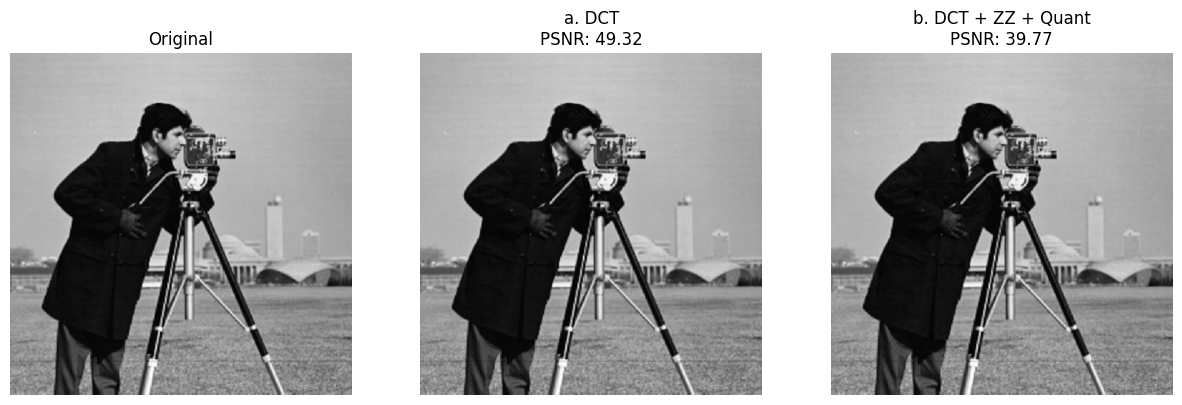

In [14]:
titles = ['Original', f'a. DCT\nPSNR: {psnr_a:.2f}', f'b. DCT + ZZ + Quant\nPSNR: {psnr_b:.2f}']
images = [img, res_a, res_b]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

In [15]:
print(f"DCT -> MSE: {mse_a:.4f}, PSNR: {psnr_a:.2f}")
print(f"DCT W/Quant and zigzag -> MSE: {mse_b:.4f}, PSNR: {psnr_b:.2f}")

DCT -> MSE: 0.7601, PSNR: 49.32
DCT W/Quant and zigzag -> MSE: 6.8612, PSNR: 39.77


## 3 Comparative Image Compression

Lossy Jpg

In [2]:
img_face = cv2.imread('face.jpg')
original_size = os.path.getsize('face.jpg') / 1024

# (High Compression)
cv2.imwrite('Face_low.jpg', img_face, [int(cv2.IMWRITE_JPEG_QUALITY), 10])
low_size = os.path.getsize('Face_low.jpg') / 1024

# (Low Compression)
cv2.imwrite('Face_high.jpg', img_face, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
high_size = os.path.getsize('Face_high.jpg') / 1024

Lossless png

In [3]:
img_butterfly = cv2.imread('Butterfly.png')
orig_bf_size = os.path.getsize('Butterfly.png') / 1024

# Save with No Compression (Level 0)
cv2.imwrite('Butterfly_0.png', img_butterfly, [int(cv2.IMWRITE_PNG_COMPRESSION), 0])
size_0 = os.path.getsize('Butterfly_0.png') / 1024

# Save with Max Compression (Level 9)
cv2.imwrite('Butterfly_9.png', img_butterfly, [int(cv2.IMWRITE_PNG_COMPRESSION), 9])
size_9 = os.path.getsize('Butterfly_9.png') / 1024

In [4]:
new_data = {
    'Butterfly (KB)': [orig_bf_size, size_9, size_0],
    'Face (KB)': [original_size, low_size, high_size]
}

df_reformatted = pd.DataFrame(new_data, index=['Original', 'Low Comp', 'High Comp'])

print(df_reformatted.to_string(formatters={'Butterfly (KB)': '{:.2f} KB'.format, 'Face (KB)': '{:.2f} KB'.format}))

          Butterfly (KB)  Face (KB)
Original       606.23 KB 1451.12 KB
Low Comp       415.86 KB  415.92 KB
High Comp     1646.82 KB 3071.71 KB


## 4

In [16]:
img = cv2.imread('penguine.jpg', 0)
logo = cv2.imread('BUlogo.png', 0)
logo_small = cv2.resize(logo, (100, 100))
h_log, w_log = logo_small.shape
rows, cols = img.shape

In [17]:
img_visible = img.copy()

roi = img_visible[rows-h_log-10:rows-10, cols-w_log-10:cols-10]
dst = cv2.addWeighted(roi, 0.7, logo_small, 0.3, 0)
img_visible[rows-h_log-10:rows-10, cols-w_log-10:cols-10] = dst

extracted_visible = img_visible[rows-h_log-10:rows-10, cols-w_log-10:cols-10]

Extraction using DCT

In [18]:
img_float = np.float32(img)
img_dct = cv2.dct(img_float)

alpha = 0.04 #Str
img_dct[10:10+h_log, 10:10+w_log] += alpha * logo_small

img_invisible = cv2.idct(img_dct)

dct_watermarked = cv2.dct(np.float32(img_invisible))
dct_original = cv2.dct(np.float32(img))
extracted_invisible = (dct_watermarked[10:10+h_log, 10:10+w_log] -
                       dct_original[10:10+h_log, 10:10+w_log]) / alpha

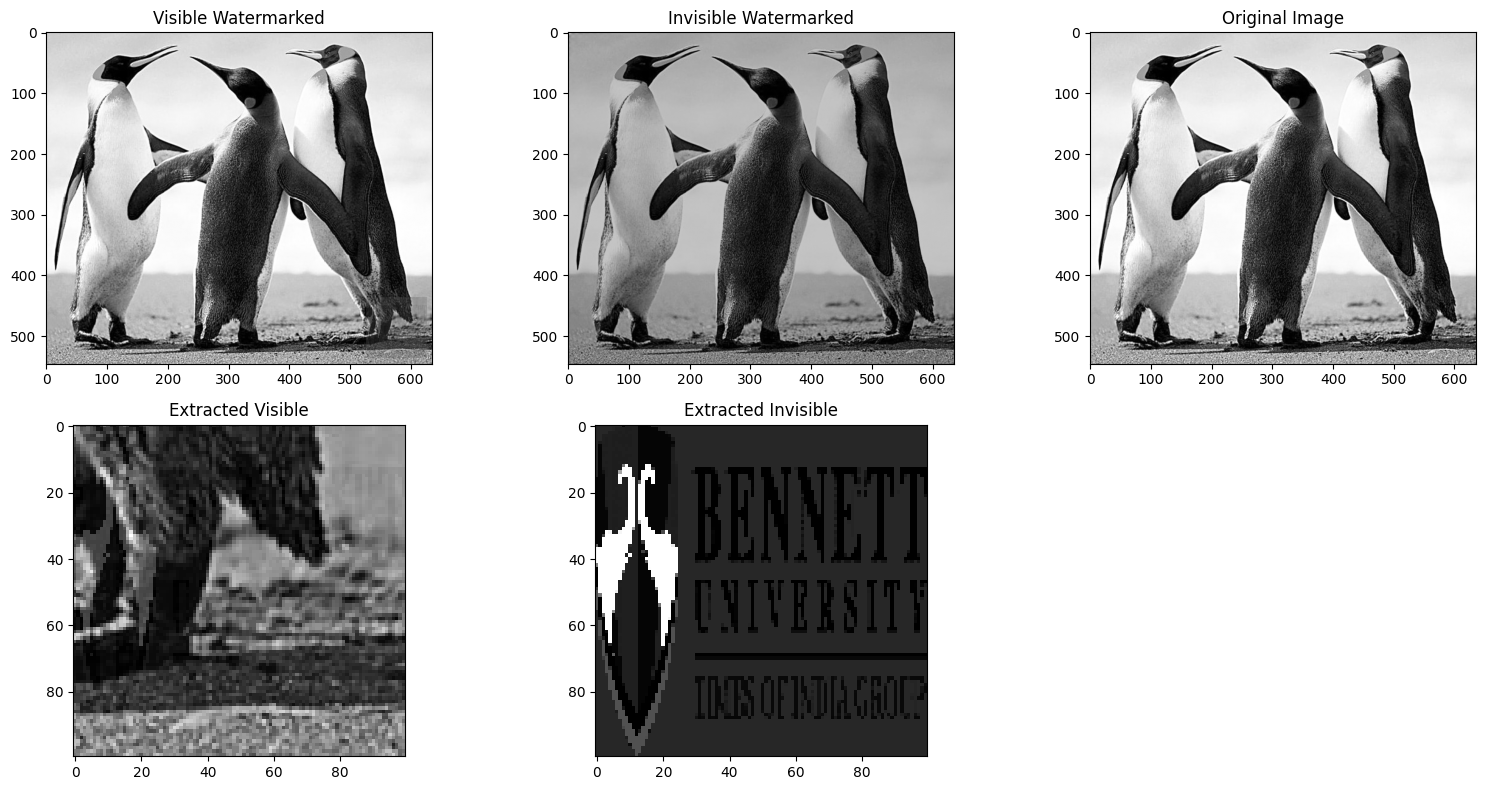

In [19]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1), plt.imshow(img_visible, cmap='gray'), plt.title('Visible Watermarked')
plt.subplot(2, 3, 4), plt.imshow(extracted_visible, cmap='gray'), plt.title('Extracted Visible')

plt.subplot(2, 3, 2), plt.imshow(img_invisible, cmap='gray'), plt.title('Invisible Watermarked')
plt.subplot(2, 3, 5), plt.imshow(extracted_invisible, cmap='gray'), plt.title('Extracted Invisible')

plt.subplot(2, 3, 3), plt.imshow(img, cmap='gray'), plt.title('Original Image')

plt.tight_layout()
plt.show()

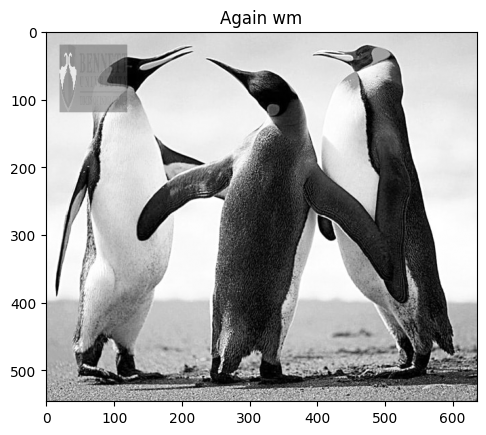

In [20]:
x_offset, y_offset = 20, 20
roi = img[y_offset:y_offset+100, x_offset:x_offset+100]

vsw = cv2.addWeighted(roi, 0.5, logo_small, 0.5, 0)

vsb = img.copy()
vsb[y_offset:y_offset+100, x_offset:x_offset+100] = vsw

plt.imshow(vsb, cmap='gray')
plt.title("Again wm")
plt.show()